In [1]:
import sys 

sys.path.append('../')

from rgb_d_trainer import RgbDepthTrainer
import torch
import numpy as np
import os
import torch.nn as nn
from functools import partial
from input_adapters import PatchedInputAdapter, SemSegInputAdapter
from dataset import MultiModalDataset, LongTransform, FirstChannelTransform
from torchvision import transforms
from output_adapters import DPTOutputAdapter, ConvNeXtAdapter
from multimae import multivit_base
from pos_embed_multi import interpolate_pos_embed_multimae
from pathlib import Path
from datetime import datetime
import logging
from configs.depth import depth_configs

import matplotlib.pyplot as plt
from PIL import Image


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# config = depth_configs()

# config.fine_tune_path = '../' + config.fine_tune_path
# config.val_dir = '../' + config.val_dir

multi_path = "/home/MultiModalCoreset/multimae/ckpt/rgb-semseg-augmented-epoch__0030_-_rmse__423.4.ckpt"
rgb_path = "/home/MultiModalCoreset/multimae/ckpt/rgb-augmented-epoch25_rmse_534.ckpt"
semseg_path = "/home/MultiModalCoreset/multimae/ckpt/semseg-epoch__0026_-_rmse__491.7.ckpt"

In [28]:
def init_rgb_model():

    device = 'cuda:0'

    ### SETUP DOMAIN ADAPTERS ###

    DOMAIN_CONF = {
        "rgb": {
            "channels": 3,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=3),
            "aug_type": "image",
        },
        "depth": {
            "channels": 1,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=1),
            "aug_type": "mask",
        },
        "mask_valid": {
            "stride_level": 1,
            "aug_type": "mask",
        },
    }

    in_domains = ['rgb']
    out_domains = ['depth']
    all_domains = list(set(in_domains) | set(out_domains))

    patch_size = 16
    input_size = 224

    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ['rgb']

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )


    ### LOAD CHECKPOINT ###
    finetune_path = rgb_path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model


def prepare_image(img):

    train_transforms = {
        "rgb": transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Resize((224, 224)),
                transforms.Normalize(
                    mean=[121.1943975, 120.18005528, 118.44828826],
                    std=[23.01586477, 22.23779258, 22.15062455],
                ),
            ]
        ),
        "semseg": transforms.Compose(
            [
                transforms.PILToTensor(),
                transforms.Resize(
                    (224, 224), interpolation=transforms.InterpolationMode.NEAREST
                ),
                FirstChannelTransform(),
                LongTransform(),
            ]
        ),
    }
    
    x = train_transforms['rgb'](img)
    sample_dict = {'rgb': x.unsqueeze(0)}

    return sample_dict

def inference(img, model):

    sample_dict = prepare_image(img)
    
    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out['depth'][0][0].numpy()

    return pred
    
def save_predictions(pred, path):
    plt.imshow(pred)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(path)


In [29]:

def init_rgb_semseg_model():
    device = "cuda:0"

    ### SETUP DOMAIN ADAPTERS ###
    semseg_num_classes = 256

    DOMAIN_CONF = {
        "rgb": {
            "channels": 3,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=3),
            "aug_type": "image",
        },
        "depth": {
            "channels": 1,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=1),
            "aug_type": "mask",
        },
        "mask_valid": {
            "stride_level": 1,
            "aug_type": "mask",
        },
        "semseg": {
            "stride_level": 1,
            "aug_type": "mask",
            "input_adapter": partial(
                SemSegInputAdapter,
                num_classes=semseg_num_classes,
                dim_class_emb=32,
                interpolate_class_emb=False,
                emb_padding_idx=semseg_num_classes,
            ),
        },
    }

    in_domains = ["rgb", "semseg"]
    out_domains = ["depth"]
    all_domains = list(set(in_domains) | set(out_domains))

    patch_size = 16
    input_size = 224

    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ["rgb", "semseg"]

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )


    ### LOAD CHECKPOINT ###
    finetune_path = multi_path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model


def prepare_multi_image(img, semseg):
    train_transforms = {
        "rgb": transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Resize((224, 224)),
                transforms.Normalize(
                    mean=[121.1943975, 120.18005528, 118.44828826],
                    std=[23.01586477, 22.23779258, 22.15062455],
                ),
            ]
        ),
        "semseg": transforms.Compose(
            [
                transforms.PILToTensor(),
                transforms.Resize(
                    (224, 224), interpolation=transforms.InterpolationMode.NEAREST
                ),
                FirstChannelTransform(),
                LongTransform(),
            ]
        ),
    }

    x = train_transforms["rgb"](img)
    semseg = train_transforms["semseg"](semseg)
    sample_dict = {"rgb": x.unsqueeze(0), "semseg": semseg.unsqueeze(0)}

    return sample_dict


def multi_inference(img, semseg, model):
    sample_dict = prepare_multi_image(img, semseg)

    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out["depth"][0][0].numpy()

    return pred


In [30]:

def init_semseg_model():
    device = "cuda:0"

    ### SETUP DOMAIN ADAPTERS ###
    semseg_num_classes = 256

    DOMAIN_CONF = {
        "rgb": {
            "channels": 3,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=3),
            "aug_type": "image",
        },
        "depth": {
            "channels": 1,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=1),
            "aug_type": "mask",
        },
        "mask_valid": {
            "stride_level": 1,
            "aug_type": "mask",
        },
        "semseg": {
            "stride_level": 1,
            "aug_type": "mask",
            "input_adapter": partial(
                SemSegInputAdapter,
                num_classes=semseg_num_classes,
                dim_class_emb=32,
                interpolate_class_emb=False,
                emb_padding_idx=semseg_num_classes,
            ),
        },
    }

    in_domains = ["semseg"]
    out_domains = ["depth"]
    all_domains = list(set(in_domains) | set(out_domains))

    patch_size = 16
    input_size = 224

    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ["semseg"]

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )


    ### LOAD CHECKPOINT ###
    finetune_path = semseg_path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model


def prepare_semseg_image(semseg):
    train_transforms = {
        "rgb": transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Resize((224, 224)),
                transforms.Normalize(
                    mean=[121.1943975, 120.18005528, 118.44828826],
                    std=[23.01586477, 22.23779258, 22.15062455],
                ),
            ]
        ),
        "semseg": transforms.Compose(
            [
                transforms.PILToTensor(),
                transforms.Resize(
                    (224, 224), interpolation=transforms.InterpolationMode.NEAREST
                ),
                FirstChannelTransform(),
                LongTransform(),
            ]
        ),
    }

    semseg = train_transforms["semseg"](semseg)
    sample_dict = {"semseg": semseg.unsqueeze(0)}

    return sample_dict


def semseg_inference(semseg, model):
    sample_dict = prepare_semseg_image(semseg)

    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out["depth"][0][0].numpy()

    return pred


In [31]:
model = init_rgb_model()
semseg = init_semseg_model()
multimodel = init_rgb_semseg_model()

<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>


In [32]:
img = Image.open('/home/data/dq/clevr_complex/train/rgb/1002_0.png').convert('RGB')
semantic = Image.open('/home/data/dq/clevr_complex/train/semseg/1002_0.png').convert('L')
depth = Image.open('/home/data/dq/clevr_complex/train/depth/1002_0.png')

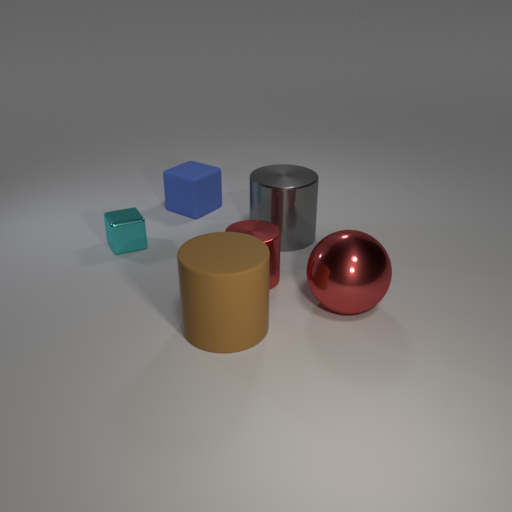

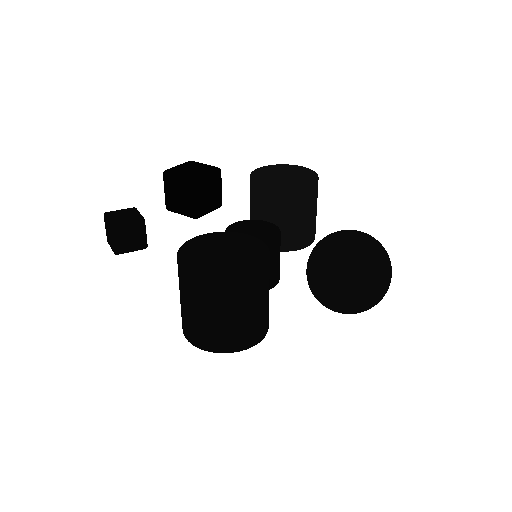

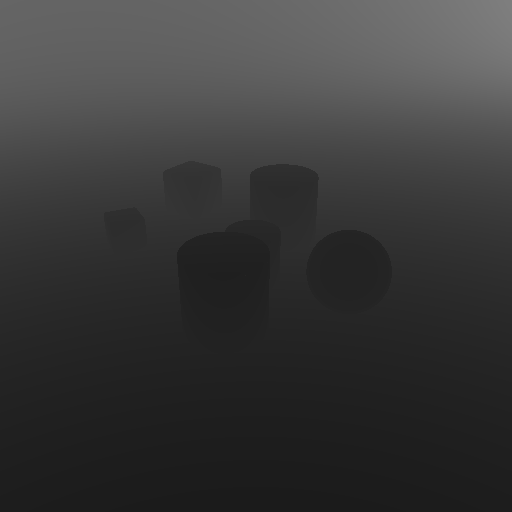

(None, None, None)

In [33]:
display(img), display(semantic), display(depth)

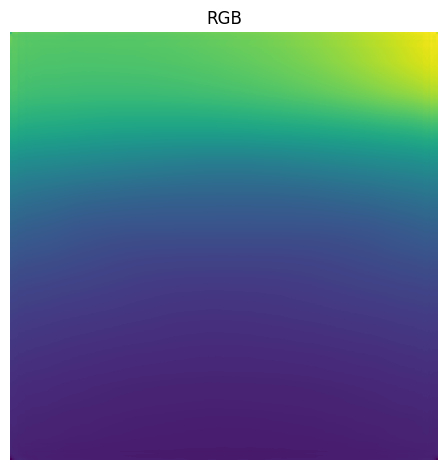

In [34]:
rgb_out = inference(img, model)
plt.imshow(rgb_out)
plt.axis('off')
plt.title('RGB')
plt.tight_layout()

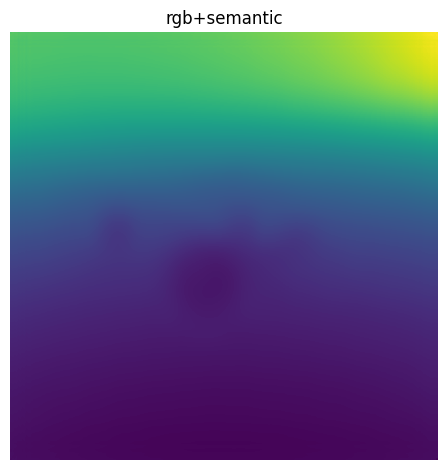

In [35]:
multi_out = multi_inference(img, semantic, multimodel)
plt.imshow(multi_out)
plt.axis('off')
plt.title('rgb+semantic')
plt.tight_layout()


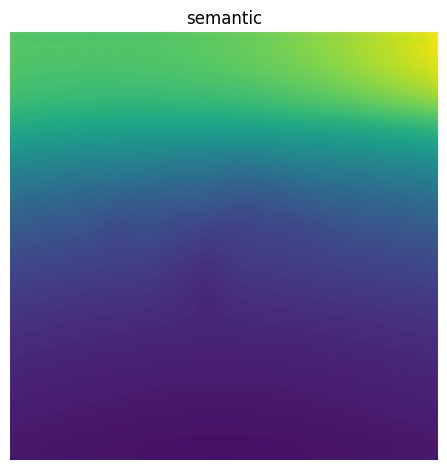

In [36]:
semseg_out = semseg_inference(semantic, semseg)
plt.imshow(semseg_out)
plt.axis('off')
plt.title('semantic')
plt.tight_layout()

In [23]:

device = "cuda:0"

### SETUP DOMAIN ADAPTERS ###
semseg_num_classes = 256

DOMAIN_CONF = {
    "rgb": {
        "channels": 3,
        "stride_level": 1,
        "input_adapter": partial(PatchedInputAdapter, num_channels=3),
        "aug_type": "image",
    },
    "depth": {
        "channels": 1,
        "stride_level": 1,
        "input_adapter": partial(PatchedInputAdapter, num_channels=1),
        "aug_type": "mask",
    },
    "mask_valid": {
        "stride_level": 1,
        "aug_type": "mask",
    },
    "semseg": {
        "stride_level": 1,
        "aug_type": "mask",
        "input_adapter": partial(
            SemSegInputAdapter,
            num_classes=semseg_num_classes,
            dim_class_emb=32,
            interpolate_class_emb=False,
            emb_padding_idx=semseg_num_classes,
        ),
    },
}

in_domains = ["rgb", "semseg"]
out_domains = ["depth"]
all_domains = list(set(in_domains) | set(out_domains))

patch_size = 16
input_size = 224

### INPUT ADAPTERS ###

input_adapters = {
    domain: DOMAIN_CONF[domain]["input_adapter"](
        stride_level=DOMAIN_CONF[domain]["stride_level"],
        patch_size_full=patch_size,
        image_size=input_size,
    )
    for domain in in_domains
}

### MAKE OUTPUT ADAPTERS ###

decoder_main_tasks = ["rgb", "semseg"]

additional_targets = {
    domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
}

# DPT settings are fixed for ViT-B. Modify them if using a different backbone.

adapters_dict = {
    "dpt": DPTOutputAdapter,
    "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
}

output_adapter = "dpt"

output_adapters = {
    domain: adapters_dict[output_adapter](
        num_classes=DOMAIN_CONF[domain]["channels"],
        stride_level=DOMAIN_CONF[domain]["stride_level"],
        patch_size=patch_size,
        main_tasks=decoder_main_tasks,
    )
    for domain in out_domains
}

### SET MODEL ###
model_name = "multivit_base"
drop_path_encoder = 0.0
model = multivit_base(
    input_adapters=input_adapters, output_adapters=output_adapters
)

ckpt_path = "../../../data/dq/mae-b_dec512d8b_1600e_multivit-c477195b.pth"

### LOAD CHECKPOINT ###
finetune_path = ckpt_path
checkpoint = torch.load(finetune_path, map_location="cpu")

checkpoint_model = checkpoint["model"]

# Interpolate position embedding
interpolate_pos_embed_multimae(model, checkpoint_model)

# Load pre-trained model
msg = model.load_state_dict(checkpoint_model, strict=False)
print(msg)
model.eval()



_IncompatibleKeys(missing_keys=['input_adapters.semseg.pos_emb', 'input_adapters.semseg.class_emb.weight', 'input_adapters.semseg.proj.weight', 'input_adapters.semseg.proj.bias', 'output_adapters.depth.scratch.layer1_rn.weight', 'output_adapters.depth.scratch.layer2_rn.weight', 'output_adapters.depth.scratch.layer3_rn.weight', 'output_adapters.depth.scratch.layer4_rn.weight', 'output_adapters.depth.scratch.layer_rn.0.weight', 'output_adapters.depth.scratch.layer_rn.1.weight', 'output_adapters.depth.scratch.layer_rn.2.weight', 'output_adapters.depth.scratch.layer_rn.3.weight', 'output_adapters.depth.scratch.refinenet1.out_conv.weight', 'output_adapters.depth.scratch.refinenet1.out_conv.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.bias', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.weight', 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.bias', 'output_adapters.depth.

MultiViT(
  (input_adapters): ModuleDict(
    (rgb): PatchedInputAdapter(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (semseg): SemSegInputAdapter(
      (class_emb): Embedding(257, 32, padding_idx=256)
      (proj): Conv2d(32, 768, kernel_size=(16, 16), stride=(16, 16))
    )
  )
  (output_adapters): ModuleDict(
    (depth): DPTOutputAdapter(
      (scratch): Module(
        (layer1_rn): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer2_rn): Conv2d(192, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer3_rn): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer4_rn): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (layer_rn): ModuleList(
          (0): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): Conv2d(192, 256, kernel_size=(3, 3), stride=(1, 1),

In [25]:
msg.missing_keys

['input_adapters.semseg.pos_emb',
 'input_adapters.semseg.class_emb.weight',
 'input_adapters.semseg.proj.weight',
 'input_adapters.semseg.proj.bias',
 'output_adapters.depth.scratch.layer1_rn.weight',
 'output_adapters.depth.scratch.layer2_rn.weight',
 'output_adapters.depth.scratch.layer3_rn.weight',
 'output_adapters.depth.scratch.layer4_rn.weight',
 'output_adapters.depth.scratch.layer_rn.0.weight',
 'output_adapters.depth.scratch.layer_rn.1.weight',
 'output_adapters.depth.scratch.layer_rn.2.weight',
 'output_adapters.depth.scratch.layer_rn.3.weight',
 'output_adapters.depth.scratch.refinenet1.out_conv.weight',
 'output_adapters.depth.scratch.refinenet1.out_conv.bias',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.weight',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv1.bias',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.weight',
 'output_adapters.depth.scratch.refinenet1.resConfUnit1.conv2.bias',
 'output_adapters.depth.scratch.refin

In [70]:
uniqs, counts = np.unique(gold, return_counts=True)

In [78]:
flattened_image = gold.flatten()

# Step 3: Count the frequency of each pixel value
pixel_values, counts = np.unique(flattened_image, return_counts=True)


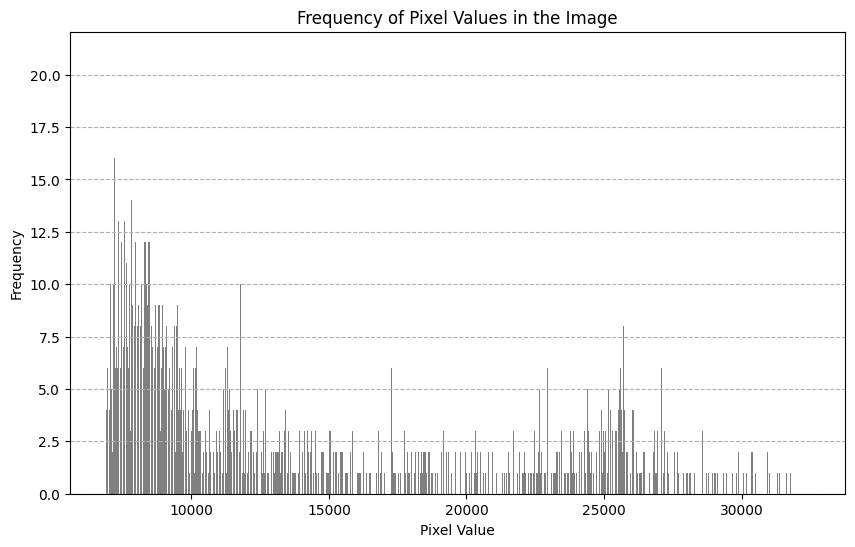

In [79]:

# Step 4: Plot the frequency of each pixel value
plt.figure(figsize=(10, 6))
plt.bar(pixel_values, counts, color='gray')
plt.title('Frequency of Pixel Values in the Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
#plt.xlim(0, 255) # Pixel values range from 0 to 255
plt.grid(axis='y', linestyle='--')
plt.show()

In [67]:
np.histogram(np.ravel(gold))

(array([19444,  7392,  4268,  2917,  2817,  2593,  3602,  4859,  1611,
          673]),
 array([ 6870. ,  9431.2, 11992.4, 14553.6, 17114.8, 19676. , 22237.2,
        24798.4, 27359.6, 29920.8, 32482. ]))

In [53]:
rgb_err = abs(rgb_out - gold)
multi_err = abs(multi_out - gold)

In [60]:
rgb_err.mean(), multi_err.mean(), rgb_err.sum() > multi_err.sum()

(286.6300665505078, 279.0759788143391, True)

In [61]:
rgb_err

array([[   2.4609375 ,  863.421875  ,  508.49609375, ...,  666.24609375,
         690.23828125,  635.76367188],
       [ 424.95117188,  632.9453125 ,  751.99609375, ...,  712.8828125 ,
         439.48828125,  212.43359375],
       [ 254.97070312,  543.34375   ,  516.07421875, ...,  606.3046875 ,
         509.49609375,  179.7109375 ],
       ...,
       [ 342.21142578,  162.11425781,  214.70214844, ...,  117.73828125,
          20.73681641,   48.79492188],
       [ 311.58447266,  463.90380859,  449.90625   , ...,  120.72558594,
         220.54736328,  157.65625   ],
       [1101.77001953,   74.42285156,  605.11474609, ...,  371.97460938,
         130.44482422,  903.53808594]])

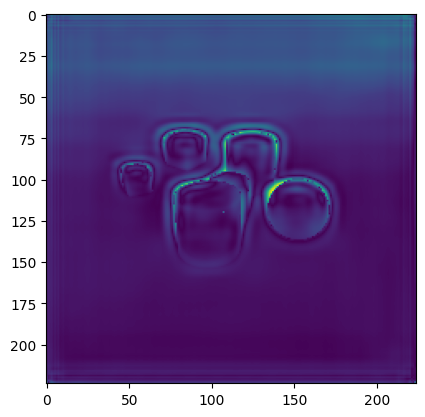

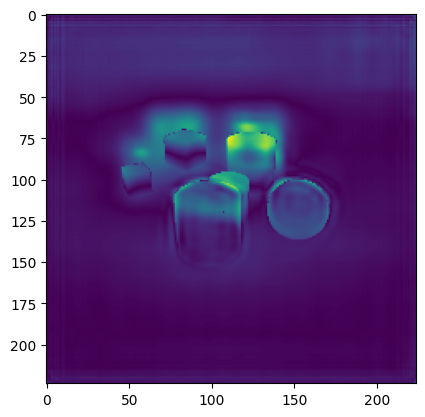

In [59]:
plt.imshow(rgb_err)
plt.show()
plt.imshow(multi_err)

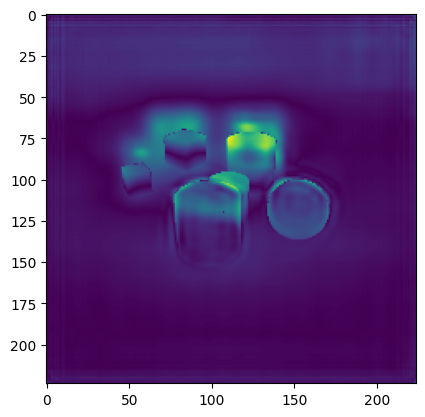

In [6]:
### MAKE TRANSFORMS ###

train_transforms = {
    "rgb": transforms.Compose(
        [transforms.ToTensor(), transforms.Resize((224, 224))]
    ),
    "semseg": transforms.Compose(
        [
            transforms.PILToTensor(),
            transforms.Resize((224, 224)),
            FirstChannelTransform(),
            LongTransform(),
        ]
    ),
}
target_transform = transforms.Compose(
    [transforms.PILToTensor(), transforms.Resize((224, 224))]
)

### MAKE DATASETS ###

val_dataset = MultiModalDataset(
    root_dir=config.val_dir,
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=target_transform,
)


In [7]:
sample_dict, target = val_dataset[0]

In [8]:
for k, v in sample_dict.items():
    sample_dict[k] = v.unsqueeze(0)

In [9]:
out = model(sample_dict, return_all_layers=True)

In [90]:
pred = out['depth'][0][0].detach()

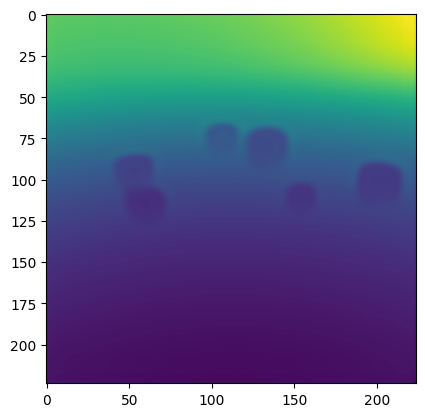

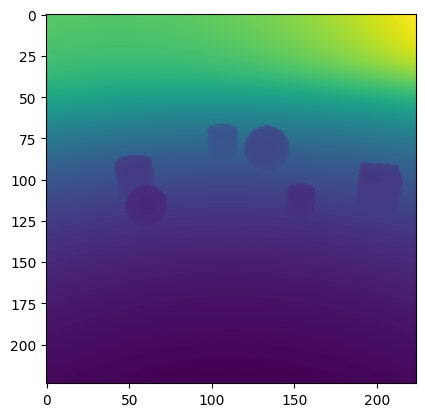

In [10]:
for i in range(1):
    sample_dict, target = val_dataset[i]
    for k, v in sample_dict.items():
        sample_dict[k] = v.unsqueeze(0)
    
    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)
    pred = out['depth'][0][0].detach()
    target = target[0]
    plt.imshow(pred.numpy())
    plt.show()
    plt.imshow(target.numpy())
    plt.show()

In [11]:
np.save('test.npy', target.numpy())

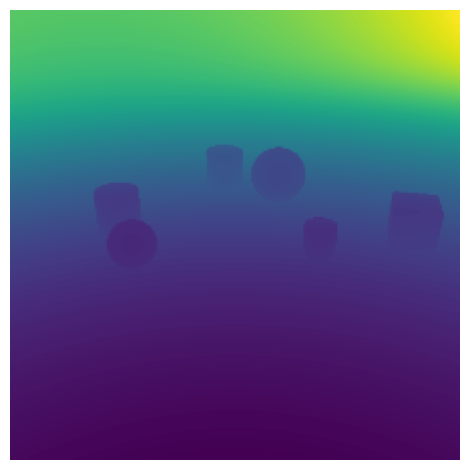

In [17]:
plt.imshow(target.numpy())
plt.axis('off')
plt.tight_layout()
plt.savefig('test.jpg')

In [50]:
notr_dataset = MultiModalDataset(
    root_dir=config.val_dir,
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=None,
)

In [60]:
d, t = notr_dataset[0]

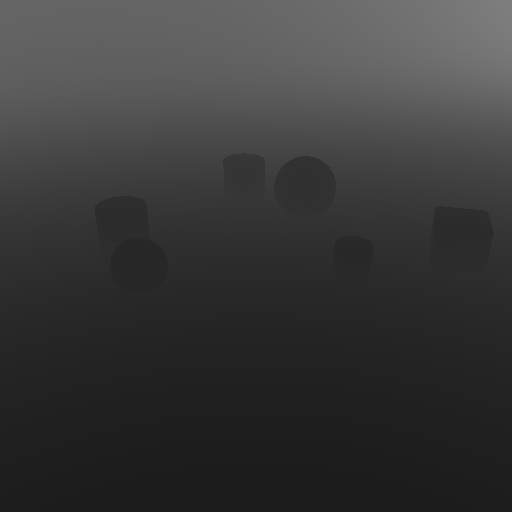

In [62]:
t.convert('L')
t

In [71]:
np.array(t).shape

(512, 512)

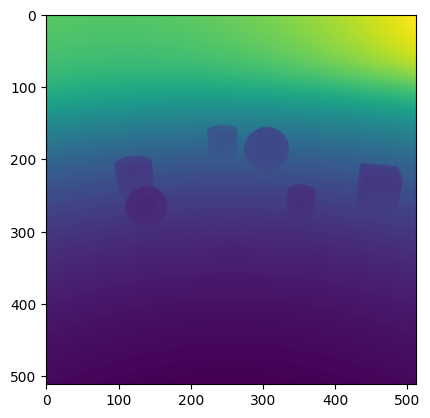

In [56]:
plt.imshow(np.array(t))